In [1]:
#!/usr/bin/env python
# coding: utf-8

# Library Import
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

# Importing Dataset
file_path = "../data/medical_clean.csv"
df = pd.read_csv(file_path)

# Display df
print(df.shape)
print(df.info())
print(df.head())

(10000, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64 

In [2]:
df = df[["Item1","Item2","Item3","Item4","Item5","Item6","Item7","Item8"]]


print(df.info())
print(f"Dataset now has {df.shape[0]} rows and {df.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Item1   10000 non-null  int64
 1   Item2   10000 non-null  int64
 2   Item3   10000 non-null  int64
 3   Item4   10000 non-null  int64
 4   Item5   10000 non-null  int64
 5   Item6   10000 non-null  int64
 6   Item7   10000 non-null  int64
 7   Item8   10000 non-null  int64
dtypes: int64(8)
memory usage: 625.1 KB
None
Dataset now has 10000 rows and 8 columns


In [3]:
df.rename(columns={
    "Item1": "Timely admission",
    "Item2": "Timely treatment",
    "Item3": "Timely visits",
    "Item4": "Reliability",
    "Item5": "Options",
    "Item6": "Hours of treatment",
    "Item7": "Courteous staff",
    "Item8": "Evidence of active listening from doctor"
}, inplace=True)

print(df.head())

   Timely admission  Timely treatment  Timely visits  Reliability  Options  \
0                 3                 3              2            2        4   
1                 3                 4              3            4        4   
2                 2                 4              4            4        3   
3                 3                 5              5            3        4   
4                 2                 1              3            3        5   

   Hours of treatment  Courteous staff  \
0                   3                3   
1                   4                3   
2                   4                3   
3                   5                5   
4                   3                4   

   Evidence of active listening from doctor  
0                                         4  
1                                         3  
2                                         3  
3                                         5  
4                                         3  


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Handle missing values if any exist
df = df.dropna() 
print(f"Dataset shape after handling missing values: {df.shape}")

Missing values per column:
Timely admission                            0
Timely treatment                            0
Timely visits                               0
Reliability                                 0
Options                                     0
Hours of treatment                          0
Courteous staff                             0
Evidence of active listening from doctor    0
dtype: int64
Dataset shape after handling missing values: (10000, 8)


In [5]:
scaler = StandardScaler()
survey_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(survey_scaled, columns=df.columns)

In [6]:
df_scaled.to_csv("medical_cleaned_clustered.csv", index=False)
print("Scaled dataset saved as 'medical_cleaned_clustered.csv'")
print(df_scaled.head())

Scaled dataset saved as 'medical_cleaned_clustered.csv'
   Timely admission  Timely treatment  Timely visits  Reliability   Options  \
0         -0.502755         -0.489673      -1.463247    -1.462128  0.488380   
1         -0.502755          0.476723      -0.494914     0.467946  0.488380   
2         -1.471828          0.476723       0.473418     0.467946 -0.482361   
3         -0.502755          1.443118       1.441750    -0.497091  0.488380   
4         -1.471828         -2.422464      -0.494914    -0.497091  1.459121   

   Hours of treatment  Courteous staff  \
0           -0.506139        -0.483672   
1            0.462548        -0.483672   
2            0.462548        -0.483672   
3            1.431236         1.474513   
4           -0.506139         0.495421   

   Evidence of active listening from doctor  
0                                  0.470420  
1                                 -0.489033  
2                                 -0.489033  
3                               

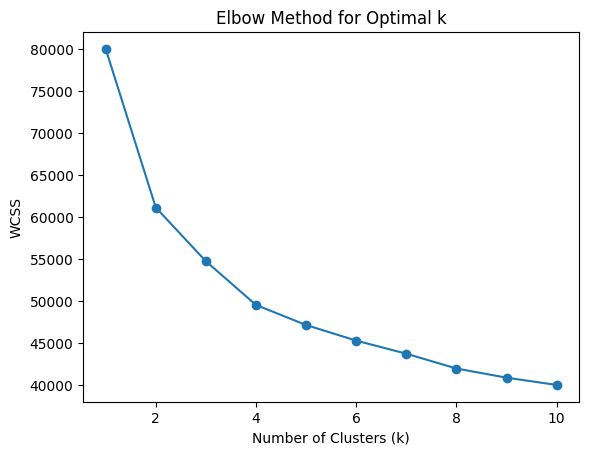

k=2, silhouette score=0.199
k=3, silhouette score=0.154
k=4, silhouette score=0.140
k=5, silhouette score=0.118
k=6, silhouette score=0.113


In [7]:
# Elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(survey_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

# Silhouette scores
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(survey_scaled)
    score = silhouette_score(survey_scaled, preds)
    print(f"k={k}, silhouette score={score:.3f}")

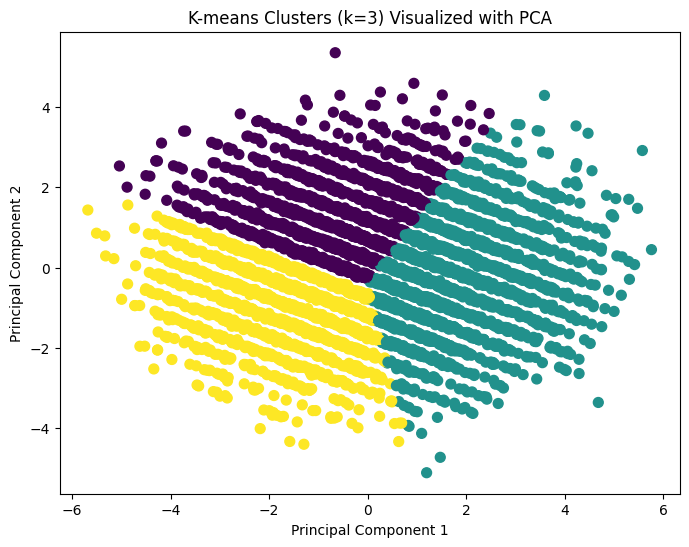

In [8]:
# From the elbow method and silhouette scores, let's choose k=3

# reduce data to 2 components for plotting
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(survey_scaled)
df["Cluster"] = clusters

pca = PCA(n_components=2)
reduced = pca.fit_transform(survey_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='viridis', s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clusters (k=3) Visualized with PCA")
plt.show()



In [9]:
# Inspect PCA loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.drop("Cluster", axis=1).columns,
    index=["PC1","PC2"]
)


print(loadings)

     Timely admission  Timely treatment  Timely visits  Reliability   Options  \
PC1          0.454769          0.428542       0.395393     0.152398 -0.190289   
PC2          0.297006          0.293257       0.296199    -0.558374  0.584190   

     Hours of treatment  Courteous staff  \
PC1            0.410537         0.356869   
PC2           -0.164001        -0.173699   

     Evidence of active listening from doctor  
PC1                                  0.312843  
PC2                                 -0.167116  


         Timely admission  Timely treatment  Timely visits  Reliability  \
Cluster                                                                   
0                3.580577          3.577238       3.597269     2.761153   
1                4.187595          4.140824       4.093035     3.928571   
2                2.495850          2.522555       2.582461     3.824612   

          Options  Hours of treatment  Courteous staff  \
Cluster                                                  
0        4.289226            3.066161         3.082246   
1        3.019573            4.256736         4.128368   
2        3.232407            3.022735         3.083003   

         Evidence of active listening from doctor  
Cluster                                            
0                                        3.122003  
1                                        4.088205  
2                                        3.149405  


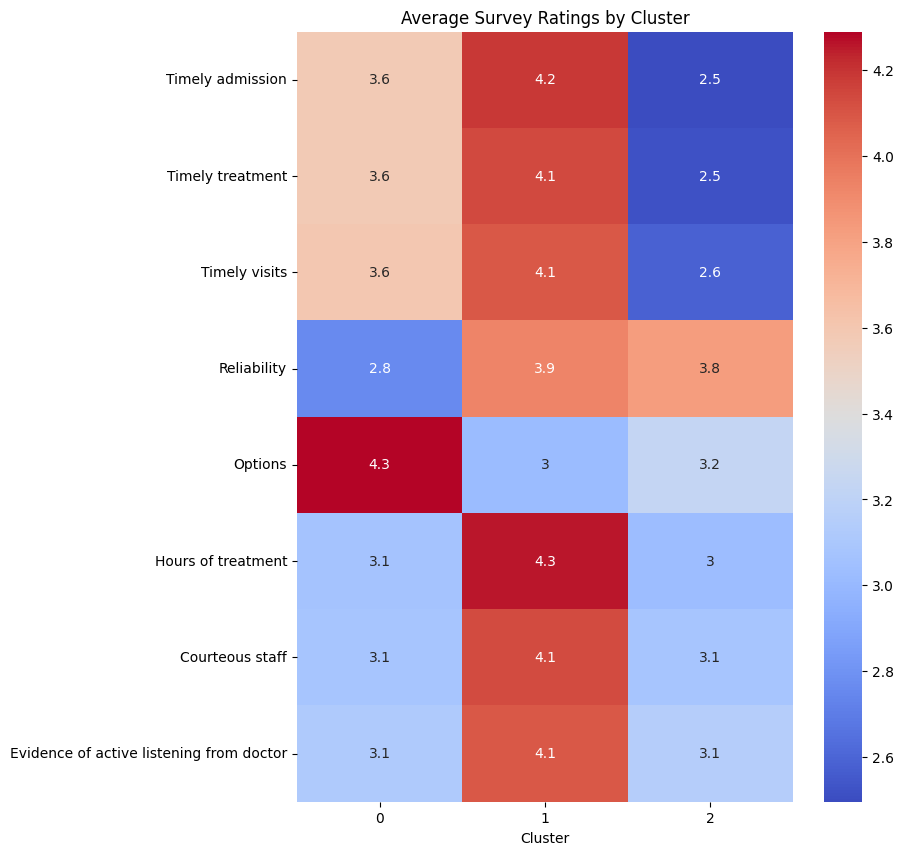

In [10]:
cluster_means = df.groupby("Cluster").mean()
print(cluster_means)


ig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(cluster_means.T, annot=True, cmap="coolwarm", cbar_kws={"orientation": "vertical"})
plt.title("Average Survey Ratings by Cluster")
plt.xlabel("Cluster")
plt.ylabel("")
plt.show()